In [29]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def tmath(b):
    return b * 134217728 / 3.93e14

def num_bytes(b):
    return (67108864 + 20480*b)

def tcomm(b):
    return num_bytes(b) / 8e11

def tcomm_vmem(b):
    return num_bytes(b) / (8e11 * 22)

def total_time(math_times, comm_times):
    return math_times + comm_times

batches = np.arange(512)

math_time = tmath(batches)  
comm_time = tcomm(batches)
comm_vmem_time = tcomm_vmem(batches)
total_t = total_time(math_time, comm_time)
max_t = np.maximum(math_time, comm_time)

In [39]:
mask = math_time > comm_time
crossover_hbm = np.argmax(mask) if mask.any() else None

mask = math_time > comm_vmem_time
crossover_vmem = np.argmax(mask) if mask.any() else None

print(f"hbm={batches[crossover_hbm]}  vmem={batches[crossover_vmem]}")

hbm=266  vmem=12


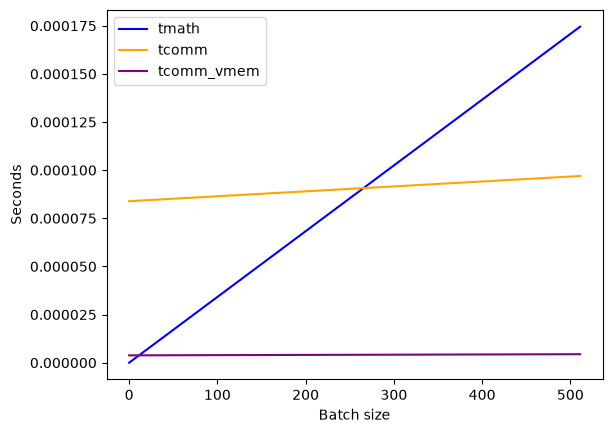

In [35]:
fig, ax = plt.subplots()
sns.lineplot(x=batches, y=math_time, ax=ax, label="tmath", color="blue")
sns.lineplot(x=batches, y=comm_time, ax=ax, label="tcomm", color="orange")
sns.lineplot(x=batches, y=comm_vmem_time, ax=ax, label="tcomm_vmem", color="purple")
# sns.lineplot(x=batches, y=total_t, ax=ax, label="total_t", color="green")
# sns.lineplot(x=batches, y=max_t, ax=ax, label="max_t", color="red", linestyle="--")
ax.set_xlabel("Batch size")
ax.set_ylabel("Seconds")
ax.legend()
plt.show()